In [ ]:
import numpy as np
import scipy.linalg as slin
import scipy.optimize as sopt
from scipy.special import expit as sigmoid
import matplotlib.pyplot as plt

from notears import utils
from notears.linear import notears_linear

# Linear Gaussian Case

## NOTEARS Alg

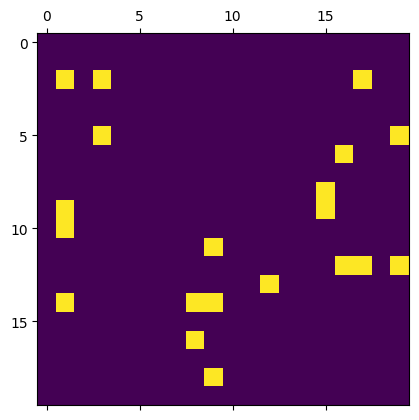

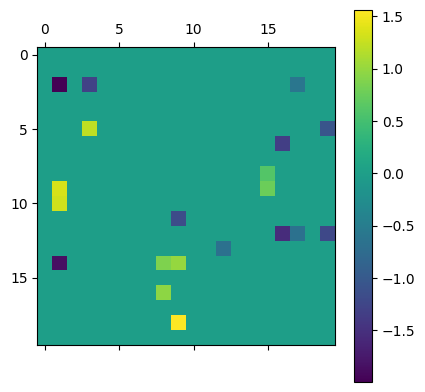

In [12]:

utils.set_random_seed(1)

n, d, s0, graph_type, sem_type = 100, 20, 20, 'ER', 'gauss'
B_true = utils.simulate_dag(d, s0, graph_type)
W_true = utils.simulate_parameter(B_true)
np.savetxt('../saves/W_true.csv', W_true, delimiter=',')

X = utils.simulate_linear_sem(W_true, n, sem_type)
np.savetxt('../saves/X.csv', X, delimiter=',')

plt.matshow(B_true)
plt.matshow(W_true)
plt.colorbar()

{'fdr': 0.0, 'tpr': 0.95, 'fpr': 0.0, 'shd': 1, 'nnz': 19}


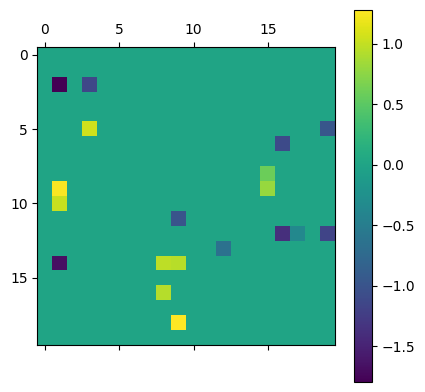

In [14]:
W_est = notears_linear(X, lambda1=0.1, loss_type='l2')
assert utils.is_dag(W_est)
np.savetxt('../saves/W_est.csv', W_est, delimiter=',')
acc = utils.count_accuracy(B_true, W_est != 0)
print(acc)
plt.matshow(W_est)
plt.colorbar()

## SysOpt with Latent Variables